# Домашняя работа (опциональная) по дисциплине «МОВС: Компьютерное зрение» 

Разбор нейросетевого модуля трекинга

<hr style="border: 1px solid rgba(50, 50, 255, 0.5); width: 100%;">

Выполнил:  
**Вольхин Данил Федорович**

Email:  
[dfvolkhin@edu.hse.ru](mailto:dfvolkhin@edu.hse.ru)

Дата:  
**10 февраля 2025**

<hr style="border: 1px solid rgba(50, 50, 255, 0.5); width: 100%;">

😊 Первый раз в жизни делаю посадку на юпитер 😊

## ANSI коды для цветов текста

In [1]:
RED = "\033[31m"
GREEN = "\033[32m"
YELLOW = "\033[33m"
BLUE = "\033[34m"
RESET = "\033[0m"  # сброс цветов до стандартных

## Шаблоны markdown

<span style="color: green;"># Это комментарий в коде</span><br>
<span style="color: blue;">def</span> greet(name):<br>
<span style="color: red;">print</span>(f"Hello, {name}!")
<hr style="border: 1px solid rgba(50, 50, 255, 0.5); width: 100%;">
<pre style="background-color: #F5F5F5; padding: 10px; border-radius: 5px; font-family: monospace;">code</pre>

## Установка библиотек (Необязательно)

In [2]:
# !pip install ultralytics pycocotools numpy scipy tqdm pillow scikit-learn albumentations pycocotools

# Подготовка к написанию кода

## Импорт библиотек

In [399]:
print(f"{YELLOW}"+60*"-"+f"{RESET}")
print(f"Библиотеки: \n")

# Дополнительные библиотеки
import platform # Узнать версию пайтона ;)
import os
import logging
import time
import sys
import random
import re
import shutil
from tqdm import tqdm
from functools import wraps
from typing import Any, Tuple, Union, Optional, List, Type, Callable, Dict
import collections
from collections import defaultdict
from collections import Counter
import zipfile
import rarfile
from dataclasses import dataclass
import tempfile

# Основные библиотеки
import IPython.display as ipd # Добавляет виджеты для ячеек юпитера
from IPython.display import HTML
from IPython import get_ipython
import ipykernel
print(f"python: {BLUE}{platform.python_version()}{RESET} ")
import matplotlib # Для рисунков
import matplotlib.pyplot as plt
print(f"matplotlib: {BLUE}{matplotlib.__version__}{RESET}")
import numpy as np # Для работы с массивами
print(f"numpy: {BLUE}{np.__version__}{RESET}")
import pandas as pd # Работа с таблицами
print(f"pandas: {BLUE}{pd.__version__}{RESET}")
import sklearn # Много полезного для ML
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.manifold import TSNE
print(f"sklearn: {BLUE}{sklearn.__version__}{RESET}")
import scipy
from scipy.spatial.distance import cdist, euclidean
from scipy.optimize import linear_sum_assignment
print(f"scipy: {BLUE}{scipy.__version__}{RESET}")
import pydantic # Для валидации данных
from pydantic import (BaseModel, Field, StrictStr, condecimal, StrictInt, StrictBool,
                      FilePath, DirectoryPath, ValidationError, root_validator, ConfigDict)
print(f"pydantic: {BLUE}{pydantic.__version__}{RESET}")
import fastapi
from fastapi import HTTPException, status
print(f"fastapi: {BLUE}{fastapi.__version__}{RESET}")
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, Dataset
print(f"torch: {BLUE}{torch.__version__}{RESET}")
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms.functional import to_pil_image
import torchvision.models as models
print(f"torchvision: {BLUE}{torchvision.__version__}{RESET}")
import requests
print(f"requests: {BLUE}{requests.__version__}{RESET}")
import PIL
from PIL import Image, ImageOps
print(f"Pillow: {BLUE}{PIL.__version__}{RESET}")
import cv2
print(f"opencv: {BLUE}{cv2.__version__}{RESET}")
import ultralytics
from ultralytics import YOLO
print(f"ultralytics: {BLUE}{ultralytics.__version__}{RESET}")
import albumentations as A
print(f"albumentations: {BLUE}{A.__version__}{RESET}")
import pycocotools
import pycocotools.mask as maskUtils
from pytorch_metric_learning import losses


from rich.theme import Theme
from rich.logging import RichHandler
from rich.console import Console
from rich.pretty import install as pretty_install
from rich.traceback import install as traceback_install


print(f"{YELLOW}"+60*"-"+f"{RESET}")

------------------------------------------------------------
Библиотеки: 

python: 3.9.0 
matplotlib: 3.7.2
numpy: 1.23.0
pandas: 2.2.2
sklearn: 1.3.2
scipy: 1.13.1
pydantic: 2.10.6
fastapi: 0.115.7
torch: 1.12.1+cu116
torchvision: 0.13.1+cu116
requests: 2.32.3
Pillow: 10.4.0
opencv: 4.9.0
ultralytics: 8.3.78
albumentations: 2.0.4
------------------------------------------------------------


## Дополнительные настройки

In [4]:
import warnings
warnings.filterwarnings("ignore")
import logging
# Отключение логирования для cmdstanpy
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
# Полезна при разработке собственных библиотек, юпитер будет переимпортировать модули, если в них были изменения
%load_ext autoreload
%autoreload 1

## Кастомный setup_logging

In [5]:
log = None

def setup_logging(clean=False, debug=False):
    global log

    if log is not None:
        return log

    try:
        if clean and os.path.isfile('setup.log'):
            os.remove('setup.log')
        time.sleep(0.1)  # prevent race condition
    except:
        pass

    if sys.version_info >= (3, 9):
        logging.basicConfig(level=logging.DEBUG, format='%(asctime)s | %(levelname)s | %(pathname)s | %(message)s',
                            filename='setup.log', filemode='a', encoding='utf-8', force=True)
    else:
        logging.basicConfig(level=logging.DEBUG, format='%(asctime)s | %(levelname)s | %(pathname)s | %(message)s',
                            filename='setup.log', filemode='a', force=True)

    console = Console(log_time=True, log_time_format='%H:%M:%S-%f', theme=Theme({
        "traceback.border": "black",
        "traceback.border.syntax_error": "black",
        "inspect.value.border": "black",
    }))
    pretty_install(console=console)
    traceback_install(console=console, extra_lines=1, width=console.width, word_wrap=False, indent_guides=False,
                      suppress=[])
    rh = RichHandler(show_time=True, omit_repeated_times=False, show_level=True, show_path=False, markup=False,
                     rich_tracebacks=True, log_time_format='%H:%M:%S-%f',
                     level=logging.DEBUG if debug else logging.INFO, console=console)
    rh.set_name(logging.DEBUG if debug else logging.INFO)
    log = logging.getLogger("sd")
    log.addHandler(rh)

    return log

In [6]:
log = setup_logging()

## Валидация входящих данных для каждого класса

### validate_with_pydantic

In [7]:
def validate_with_pydantic(model_cls):
    """
    Декоратор для валидации данных с использованием Pydantic-модели.
    """

    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            # Проверяем данные в аргументах функции
            try:
                data = kwargs.get("entry", args[0] if args else None)
                if not data:
                    raise HTTPException(status_code=status.HTTP_400_BAD_REQUEST,
                                        detail="No data provided for validation.")
                # Валидация данных
                if isinstance(data, BaseModel):
                    data = data.dict(by_alias=True)
                validated_data = model_cls(**data)
                # Передаем валидированные данные дальше
                kwargs["entry"] = validated_data
                return func(*args, **kwargs)
            except ValidationError as ve:
                log.exception("Validation failed", exc_info=ve)
                raise HTTPException(status_code=status.HTTP_400_BAD_REQUEST,
                                    detail="Invalid data for Pydantic model.") from ve

        return wrapper

    return decorator

### auto_generate_docstring

In [8]:
def auto_generate_docstring(cls: Type[BaseModel]) -> Type[BaseModel]:
    """
    Декоратор для автоматического добавления docstring в классы Pydantic.
    """

    def generate_docstring(model: Type[BaseModel]) -> str:
        """
        Генерация строки документации из описания полей модели Pydantic.
        """
        docstring = []
        for field_name, field_info in model.__fields__.items():
            field_details = f"Field '{field_name}':\n"
            if field_info.description:  # Получение описания
                field_details += f"  Description: {field_info.description}\n"
            if field_info.examples:  # Получение примеров
                field_details += f"  Examples: {field_info.examples}\n"
            docstring.append(field_details)
        return "\n".join(docstring)

    # Добавляем описание к существующему docstring
    cls.__doc__ = (cls.__doc__ or "") + "\n\n" + generate_docstring(cls)
    return cls

### EntryGraduateModel

In [338]:
@auto_generate_docstring
class EntryGraduateModel(BaseModel):
    """
    Класс для валидации входных данных EntryGraduateModel
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)
    Prefix: Optional[StrictStr] = Field("",
                                        alias="prefix",
                                        examples=["exp1"],
                                        descripton="Префикс к названию модели")
    Models: list[str] = Field(...,
                              alias="models",
                              examples=[["efficientnet_b0", "efficientnet_b1"]],
                              description="Список моделей для обучения")
    NameOptimizers: list[str] = Field(...,
                                      alias="name_optimizers",
                                      examples=[["Adam"]],
                                      description="Лист с названиями оптимизаторов из доступных в torch.nn.optim для каждой модели")
    EmbSize: Optional[StrictInt] = Field(512,
                                         alias="emb_size",
                                         examples=[512],
                                         description="Размер ембеддинга сиамской сети")
    UseImageNetWeights: Optional[bool] = Field(False,
                                               alias="is_use_imagenet_weights",
                                               examples=[True],
                                               description="Использовать предобученные веса ImageNet?")
    SizeImg: Optional[tuple] = Field((64, 64),
                                     alias="size_img",
                                     examples=[(224, 224)],
                                     description="Размер изображения для обучения")
    EmbSize: StrictInt = Field(1024,
                               alias="emb_size",
                               examples=[1024],
                               description="Размер эмбеддинга модели")
    PathData: Optional[StrictStr] = Field("./data",
                                          alias="path_to_data",
                                          examples=["./data"],
                                          description="Путь к директории с данными. Дефолтный путь ./data")
    PathWeights: Optional[StrictStr] = Field("./weights",
                                             alias="path_to_weights",
                                             examples=["./weights"],
                                             description="Если сохраняем веса, то куда? Дефолтный путь ./weights")
    PathMetricsTrain: Optional[StrictStr] = Field("./metrics_train",
                                                  alias="path_to_metrics_train",
                                                  examples=["./metrics_train"],
                                                  description="Куда сохраняем тренировочные метрики? Дефолтный путь ./metrics_train")
    PathMetricsTest: Optional[StrictStr] = Field("./metrics_test",
                                                 alias="path_to_metrics_test",
                                                 examples=["./metrics_test"],
                                                 description="Куда сохраняем тестовые метрики? Дефолтный путь ./metrics_test")
    PathSavePlots: Optional[StrictStr] = Field("./plot",
                                               alias="path_to_save_plots",
                                               examples=["./plot"],
                                               description="Куда сохраняем графики результатов обучения? Дефолтный путь ./plot")
    UseDevice: Optional[StrictStr] = Field(None,
                                           alias="use_device",
                                           examples=["cuda"],
                                           description="Какое устройство использовать? cpu/cuda")
    StartLerningRate: Optional[condecimal(ge=0.00000001, le=0.01, decimal_places=8)] = Field(0.0001,
                                                                                             alias="start_learning_rate",
                                                                                             examples=[0.0001],
                                                                                             description="Начальная величина шага градиентного спуска")
    BatchSize: Optional[StrictInt] = Field(1,
                                           alias="batch_size",
                                           examples=[10],
                                           description="Размер пакета при обучении")
    NumWorkers: Optional[StrictInt] = Field(0,
                                            alias="num_workers",
                                            examples=[0],
                                            description="Кол. используемых потоков при подгрузке данных DataLoader (0 это 1)")
    PinMemory: Optional[StrictBool] = Field(False,
                                            alias="pin_memory",
                                            examples=[False],
                                            description="Если True ускоряет загрузку данных на видеокарте, для cpu всегда False")
    NumEpochs: Optional[StrictInt] = Field(3,
                                           alias="num_epochs",
                                           examples=[20],
                                           description="Количество эпох обучения для каждой модели")
    Seed: Optional[StrictInt] = Field(17,
                                      alias="seed",
                                      examples=[17],
                                      description="Сажает зерно")

### EntryInferenceModel

In [353]:
@auto_generate_docstring
class EntryInferenceModel(BaseModel):
    """
    Класс для валидации входных данных EntryInferenceModel
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)
    Prefix: Optional[StrictStr] = Field("",
                                        alias="prefix",
                                        examples=["exp1"],
                                        descripton="Префикс к названию модели")
    NameModel: StrictStr = Field(...,
                                 alias="name_model",
                                 examples=["efficientnet_b0_2024_10_02)"],
                                 description="Название файла .pt")
    ImageList: list[StrictStr] = Field(...,
                                       alias="image_path_list",
                                       examples=[["./images/image.jpg"]],
                                       description="Список путей к изображениям")
    SizeImg: Optional[tuple] = Field((64, 64),
                                     alias="size_img",
                                     examples=[(224, 224)],
                                     description="Размер изображения для инференса")
    EmbSize: StrictInt = Field(1024,
                               alias="emb_size",
                               examples=[1024],
                               description="Размер эмбеддинга модели")
    PathWeights: Optional[StrictStr] = Field("./weights",
                                             alias="path_to_weights",
                                             examples=["./weights"],
                                             description="Путь к папке, где хранятся веса модели? Дефолтный путь ./weights")
    UseDevice: Optional[StrictStr] = Field(None,
                                           alias="use_device",
                                           examples=["cuda"],
                                           description="Какое устройство использовать? cpu/cuda")
    Labels: Optional[bool] = Field(False,
                                   alias="labels",
                                   examples=["True"],
                                   description="Есть ли в названиях файлов метки? Да/нет")

# Загрузка и предобработка данных

## Загрузка и распаковка набор данных PKU-Reid-Dataset

In [11]:
class PKUReidDatasetDownloader:
    def __init__(self, download_url, target_dir='data'):
        self.download_url = download_url
        self.target_dir = target_dir
        self.dataset_zip = os.path.join(self.target_dir, 'PKU-Reid-Dataset.zip')
        os.makedirs(self.target_dir, exist_ok=True)

    def download_dataset(self):
        """Скачивание архива с датасетом"""
        response = requests.get(self.download_url, stream=True)
        total_size = int(response.headers.get('content-length', 0))
        
        with open(self.dataset_zip, 'wb') as file, tqdm(
            desc="Downloading PKU-Reid Dataset",
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024
        ) as bar:
            for data in response.iter_content(chunk_size=1024):
                file.write(data)
                bar.update(len(data))

    def extract_dataset(self):
        """Распаковка архива"""
        with zipfile.ZipFile(self.dataset_zip, 'r') as zip_ref:
            zip_ref.extractall(self.target_dir)

    def organize_dataset(self):
        """Организация данных в структуру train/val/test"""
        source_folder = os.path.join(self.target_dir, 'PKUv1a_128x48')
        if not os.path.exists(source_folder):
            raise FileNotFoundError(f"Dataset folder {source_folder} not found!")
        
        # Создаем целевую структуру директорий
        splits = {
            'train': (1, 80),
            'val': (81, 97),
            'test': (98, 114)
        }
        
        for split, (start, end) in splits.items():
            split_dir = os.path.join(self.target_dir, split)
            os.makedirs(split_dir, exist_ok=True)
            
            # Фильтрация и перемещение файлов
            files = os.listdir(source_folder)
            for file in files:
                person_id = int(file.split('_')[0])
                if start <= person_id <= end:
                    src = os.path.join(source_folder, file)
                    dst = os.path.join(split_dir, file)
                    shutil.move(src, dst)
        
        # Удаление временных файлов
        shutil.rmtree(source_folder)
        os.remove(self.dataset_zip)

    def visualize_person(self, person_id, split=None):
        """Визуализация всех изображений конкретного человека"""
        splits = ['train', 'val', 'test'] if split is None else [split]
        found_images = []
        
        for split_name in splits:
            split_dir = os.path.join(self.target_dir, split_name)
            if not os.path.exists(split_dir):
                continue
                
            # Поиск файлов по ID
            files = [f for f in os.listdir(split_dir) 
                    if int(f.split('_')[0]) == person_id]
            
            # Сортировка по камере и номеру кадра
            files.sort(key=lambda x: (int(x.split('_')[1]), 
                                     int(x.split('_')[2].split('.')[0])))
            
            found_images.extend([os.path.join(split_dir, f) for f in files])
        
        # Отрисовка изображений
        if not found_images:
            print(f"No images found for person {person_id}")
            return
            
        plt.figure(figsize=(20, 3))
        for i, img_path in enumerate(found_images):
            plt.subplot(1, len(found_images), i+1)
            img = Image.open(img_path).convert('RGB')
            plt.imshow(img)
            plt.axis('off')
            plt.title(os.path.basename(img_path))
        plt.tight_layout()
        plt.show()

    def download_and_prepare(self):
        """Полный цикл подготовки данных"""
        self.download_dataset()
        self.extract_dataset()
        self.organize_dataset()

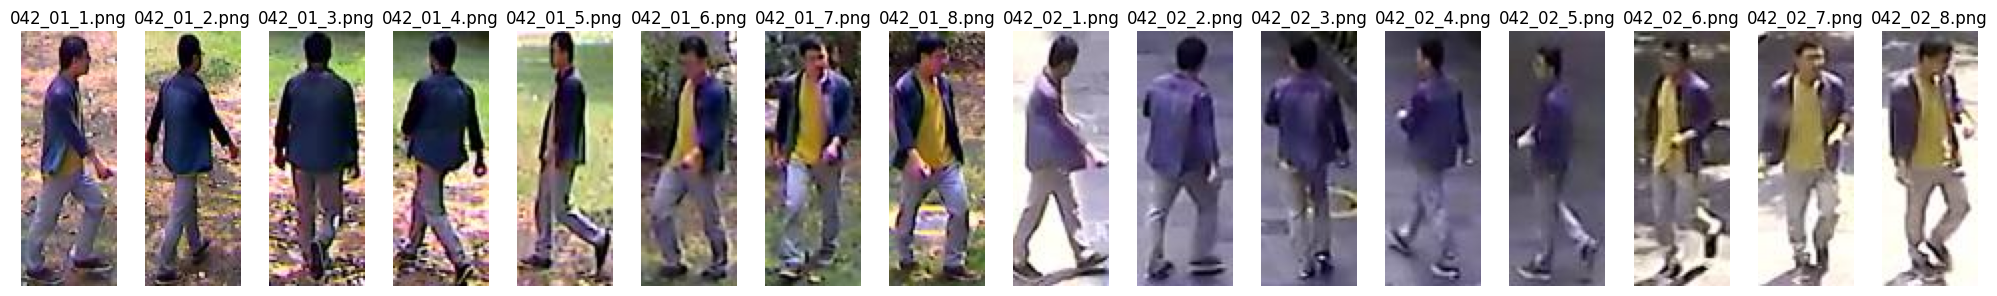

In [12]:
dataset_url = "https://drive.usercontent.google.com/u/0/uc?id=0B176otcbAxRITkRWYUwyYVBkMVk&export=download&resourcekey=0-bPhkAU1UdM_6INm0XGCNBw"
downloader = PKUReidDatasetDownloader(download_url=dataset_url)
downloader.download_and_prepare()
# Визуализация человека с ID=42 из обучающей выборки
downloader.visualize_person(42, split='train')

## Формирование датасета для обучения

### Класс SiameseDataset

In [276]:
class SiameseDataset(Dataset):
    def __init__(self, root_dir: str, transform: Optional[callable] = None) -> None:
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_to_indices = defaultdict(list)
        self._prepare_dataset()

    def _prepare_dataset(self):
        for subdir, _, files in os.walk(self.root_dir):
            for file in files:
                if file.endswith('.png'):
                    label = int(file.split('.png')[0].split('_')[0])
                    full_path = os.path.join(subdir, file)
                    self.image_paths.append(full_path)
                    self.labels.append(label)
        
        self.labels = np.array(self.labels)
        
        # Создаем словарь для быстрого доступа к индексам по меткам
        for idx, label in enumerate(self.labels):
            self.label_to_indices[label].append(idx)

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # Получаем первое изображение
        anchor_path = self.image_paths[index]
        anchor_label = self.labels[index]
        
        # Генерируем пару
        if random.random() < 0.5:
            # Положительная пара (одинаковый класс)
            same_class_indices = [i for i in self.label_to_indices[anchor_label] if i != index]
            if not same_class_indices:
                # Если нет других изображений в классе, создаем отрицательную пару
                positive = False
            else:
                pair_index = random.choice(same_class_indices)
                positive = True
        else:
            # Отрицательная пара (разные классы)
            positive = False

        if not positive:
            # Выбираем случайный другой класс
            other_labels = [l for l in self.label_to_indices.keys() if l != anchor_label]
            if not other_labels:
                # Если только один класс в датасете
                raise RuntimeError("Dataset contains only one class")
            chosen_label = random.choice(other_labels)
            pair_index = random.choice(self.label_to_indices[chosen_label])

        # Загружаем и преобразуем изображения
        anchor_img = Image.open(anchor_path).convert('RGB')
        pair_img = Image.open(self.image_paths[pair_index]).convert('RGB')
        
        if self.transform:
            anchor_img = self.transform(anchor_img)
            pair_img = self.transform(pair_img)

        return (
            anchor_img,
            pair_img,
            torch.tensor(1.0 if positive else 0.0, dtype=torch.float32)
        )

### Класс SimpleDataset

In [277]:
class SimpleDataset(Dataset):
    def __init__(self, root_dir: str, transform: Optional[callable] = None) -> None:
        """
        Инициализация датасета для валидации и тестирования.
        
        :param root_dir: корневая директория с изображениями
        :param transform: преобразования для изображений
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self._prepare_dataset()

    def _prepare_dataset(self) -> None:
        """Сбор данных и меток из файловой структуры."""
        for root, _, files in os.walk(self.root_dir):
            for file in files:
                if file.endswith('.png'):
                    file_path = os.path.join(root, file)
                    label = int(file.split('.png')[0].split('_')[0])
                    self.image_paths.append(file_path)
                    self.labels.append(label)

    def __len__(self) -> int:
        """Возвращает общее количество изображений."""
        return len(self.image_paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Возвращает тензор изображения и соответствующую метку."""
        img_path = self.image_paths[index]
        label = self.labels[index]
        
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return (
            img,  # Тензор изображения [C, H, W]
            torch.tensor(label, dtype=torch.long)  # Метка класса
        )

### Класс ResizeWithPadding

In [278]:
# Класс для приведения изображения к заданному размеру
class ResizeWithPadding:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        # Приведение изображения к нужному размеру с сохранением соотношения сторон
        img.thumbnail((self.size, self.size), Image.Resampling.LANCZOS)

        # Добавление паддингов
        delta_width = self.size - img.size[0]
        delta_height = self.size - img.size[1]
        padding = (delta_width // 2, delta_height // 2, delta_width - (delta_width // 2), delta_height - (delta_height // 2))

        new_img = ImageOps.expand(img, padding, fill=(0, 0, 0))

        return new_img

### Визуализация данных для обучения

In [287]:
def visualize_augmentations(dataset, person_ids, n_samples=8):
    fig, axs = plt.subplots(len(person_ids), n_samples, figsize=(15, 5))
    
    for i, person_id in enumerate(person_ids):
        # Фильтруем изображения по ID
        indices = [idx for idx, label in enumerate(dataset.labels) if label == person_id]
        selected_indices = np.random.choice(indices, n_samples, replace=False)
        
        for j, idx in enumerate(selected_indices):
            img_tensor, label = dataset[idx]
            
            # Конвертируем тензор в PIL Image
            img = to_pil_image(img_tensor)
            
            axs[i,j].imshow(img)
            axs[i,j].axis('off')
            if j == 0:
                axs[i,j].set_title(f'ID: {person_id}')
    
    plt.tight_layout()
    plt.show()

In [296]:
def visualize_siamese_pairs(dataset, num_pairs=5):
    """
    Визуализация пар изображений из SiameseDataset.
    
    :param dataset: экземпляр SiameseDataset
    :param num_pairs: количество пар для отображения
    """
    fig, axs = plt.subplots(num_pairs, 2, figsize=(10, 2 * num_pairs))
    
    for i in range(num_pairs):
        # Получаем случайный индекс из датасета
        idx = np.random.randint(0, len(dataset))
        
        # Загружаем пару изображений и метку
        anchor_img, pair_img, label = dataset[idx]
        
        # Конвертируем тензоры в PIL Image
        anchor_img = to_pil_image(anchor_img)
        pair_img = to_pil_image(pair_img)
        
        # Отображаем изображения
        axs[i, 0].imshow(anchor_img)
        axs[i, 0].axis('off')
        axs[i, 0].set_title("Anchor Image")
        
        axs[i, 1].imshow(pair_img)
        axs[i, 1].axis('off')
        axs[i, 1].set_title(f"Pair Image (Label: {'Positive' if label == 1 else 'Negative'})")
    
    plt.tight_layout()
    plt.show()

In [300]:
# Преобразования для обучающего набора данных
train_transforms = transforms.Compose([
    ResizeWithPadding(128),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2, 
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor()
])

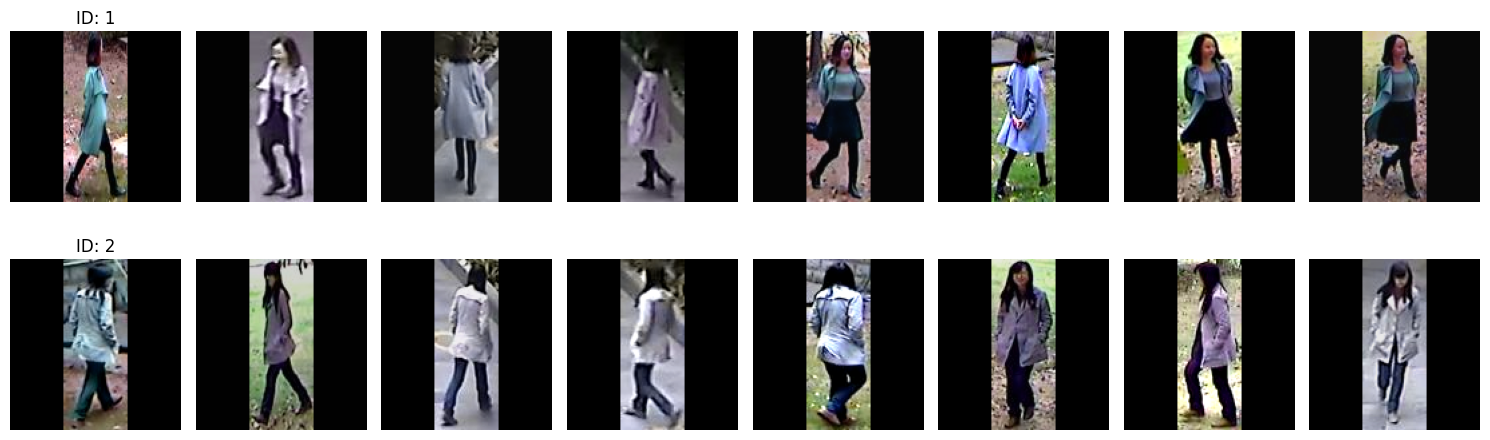

In [301]:
# Создаем временный SimpleDataset с тренировочными трансформациями
vis_dataset = SimpleDataset(root_dir='data/train', transform=train_transforms)
# Визуализируем первые два ID
visualize_augmentations(vis_dataset, person_ids=[1, 2])

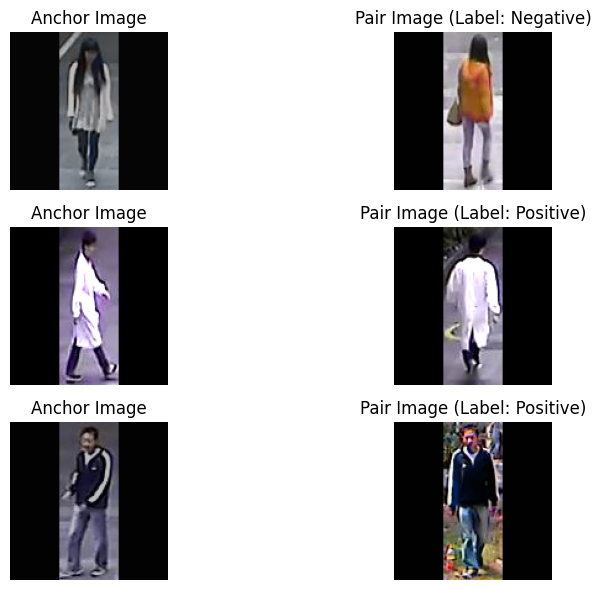

In [302]:
# Создаем временный SiameseDataset с тренировочными трансформациями
vis_dataset = SiameseDataset(root_dir='data/train', transform=train_transforms)
# Визуализируем 5 случайных пар
visualize_siamese_pairs(vis_dataset, num_pairs=3)

# Сиамская нейронная сеть

## Класс SiameseNetwork

![siamese_network](https://habrastorage.org/webt/vz/r1/ch/vzr1ch09luydotrwrqc26ccyn-u.jpeg)

In [303]:
class SiameseNetwork(nn.Module):
    def __init__(
        self, 
        name_model: str,
        emb_size: int = 512,
        imagenet: bool = True
    ):
        super().__init__()

        # Инициализируем параметры
        self.name_model = name_model
        self.emb_size = emb_size
        self.imagenet = imagenet
        
        # Получение списка доступных моделей
        self.model_list = sorted(name for name in models.__dict__
                                 if name.islower() and not name.startswith("__")
                                 and name != "get_weight"
                                 and callable(models.__dict__[name]))
        # Инициализируем архитектуру модели
        self.get_model()

        in_features = self.emb_size

        # Первая ветка полносвязных слоев
        self.fc = nn.Sequential(
            nn.Linear(in_features, self.emb_size * 2),
            nn.Tanh(),
            nn.Linear(self.emb_size * 2, self.emb_size * 2),
            nn.Tanh(),
            nn.Linear(self.emb_size * 2, self.emb_size * 2),
            nn.Tanh(),
            nn.Linear(self.emb_size * 2, self.emb_size),
        )

    def get_model(self):
        # Проверка доступности модели в torchvision
        if self.name_model in self.model_list:
            # Проверка доступности весов ImageNet
            if self.imagenet:
                try:
                    if self.name_model in ["inception_v3", "googlenet"]:
                        # Попытка загрузки модели с весами ImageNet
                        self.model = models.__dict__[self.name_model](init_weights=True)
                    else:
                        if self.name_model in ["regnet_y_128gf", "vit_h_14"]:
                            self.model = models.__dict__[self.name_model](weights="IMAGENET1K_SWAG_E2E_V1")
                        else:
                            self.model = models.__dict__[self.name_model](weights="IMAGENET1K_V1")
                except KeyError:
                    # Если веса ImageNet для данной модели недоступны, загрузка без весов
                    print(
                        f"Предобученные веса ImageNet для модели {self.name_model} недоступны."
                        f" Загрузка модели без предобученных весов.")
                    if self.name_model in ["inception_v3", "googlenet"]:
                        # Попытка загрузки модели с весами ImageNet
                        self.model = models.__dict__[self.name_model](init_weights=False)
                    else:
                        self.model = models.__dict__[self.name_model](weights=None)
            else:
                # Если не указано использование весов ImageNet, загрузить модель без них
                if self.name_model in ["inception_v3", "googlenet"]:
                    self.model = models.__dict__[self.name_model](init_weights=False)
                else:
                    self.model = models.__dict__[self.name_model](weights=None)

            try:
                name_without_numbers = re.sub(r'\d+', '', self.name_model)
                # Проверка доступности слоя classifier
                if hasattr(self.model, 'classifier'):
                    if name_without_numbers == "densenet":
                        num_features = self.model.classifier.in_features
                        self.model.classifier = nn.Linear(num_features, self.emb_size)
                    elif name_without_numbers == "squeezenet_":
                        num_features = 512
                        self.model.classifier[-1] = nn.Linear(num_features, self.emb_size)
                    else:
                        num_features = self.model.classifier[-1].in_features
                        self.model.classifier[-1] = nn.Linear(num_features, self.emb_size)
                elif hasattr(self.model, 'last_linear'):
                    num_features = self.model.last_linear.in_features
                    self.model.last_linear = nn.Linear(num_features, self.emb_size)
                elif hasattr(self.model, 'fc'):
                    num_features = self.model.fc.in_features
                    self.model.fc = nn.Linear(num_features, self.emb_size)
                elif hasattr(self.model, 'head'):
                    num_features = self.model.head.in_features
                    self.model.head = nn.Linear(num_features, self.emb_size)
                elif hasattr(self.model, "heads"):
                    num_features = self.model.heads[0].in_features
                    self.model.heads[0] = nn.Linear(num_features, self.emb_size)
                else:
                    print(f"Слой classifier не найден в модели. name_model:{self.name_model}")
            except Exception as ex:
                print(f"Exception: {ex}, name_model: {self.name_model}")
        else:
            print(f"Модель {self.name_model} не найдена в torchvision."
                  f"\nСписок доступных моделей: {self.model_list}")

    def forward_once(self, x: torch.Tensor) -> torch.Tensor:
        """
        Обработка одного изображения через выбранную ветку.

        :param x: входное изображение
        :param branch: номер ветки (1 или 2)
        :return: эмбеддинг изображения
        """
        features = self.model(x)
        return self.fc(features)

    def forward(self, input1: torch.Tensor, input2: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Обработка пары изображений через две ветки.

        :param input1: первое изображение
        :param input2: второе изображение
        :return: два эмбеддинга (от первой и второй ветки)
        """
        # Первое изображение обрабатывается через первую ветку
        embedding1 = self.forward_once(input1)
        
        # Второе изображение обрабатывается через вторую ветку
        embedding2 = self.forward_once(input2)
        
        return embedding1, embedding2

# Контрастивная функция потерь

## Класс ContrastiveLoss

![contrastive_loss](https://habrastorage.org/r/w1560/getpro/habr/upload_files/a39/221/e95/a39221e9584cb152b72068da158a0c35.png)

$L = y * ||f(I_{p}) - f(I_{q})||_{2}^{2} + (1 - y) * max({0, m - ||f(I_{p}) - f(I_{q})||_{2}})^{2}$

In [304]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1: torch.Tensor, output2: torch.Tensor, label: torch.Tensor) -> torch.Tensor:
        # Вычисляем Евклидово расстояние между эмбеддингами
        euclidean_distance = F.pairwise_distance(output1, output2)
        
        # Вычисляем потери для похожих и разных пар
        loss_similar = label * torch.pow(euclidean_distance, 2)
        loss_dissimilar = (1 - label) * torch.pow(
            torch.clamp(self.margin - euclidean_distance, min=0.0), 
            2
        )
        
        # Усредняем потери по батчу
        loss_contrastive = torch.mean(loss_similar + loss_dissimilar)
        return loss_contrastive

# Функция для расчета метрики mAP

In [305]:
def calculate_map(all_embs: List[np.ndarray], all_labels: List[int]) -> float:
    """
    Вычисление среднего значения AP (mAP) для всех эмбеддингов и их меток.

    :param all_embs: список эмбеддингов изображений.
    :param all_labels: список меток (id), соответствующих эмбеддингам.
    :return: mAP.
    """
    aps = []
    
    for idx in range(len(all_labels)):
        # Создаем временные копии данных
        embs = all_embs.copy()
        labels = all_labels.copy()
        
        # Извлекаем якорь и удаляем его из списков
        anchor_emb = embs.pop(idx)
        anchor_label = labels.pop(idx)
        
        # Преобразуем в numpy массивы
        embs_array = np.array(embs)
        anchor_array = np.array(anchor_emb)
        
        # Вычисляем евклидовы расстояния
        distances = np.linalg.norm(embs_array - anchor_array, axis=1)
        
        # Сортируем метки по расстояниям
        sorted_indices = np.argsort(distances)
        sorted_labels = np.array(labels)[sorted_indices]
        
        # Вычисляем AP для текущего якоря
        correct = (sorted_labels == anchor_label)
        relevant = np.where(correct)[0]
        
        if len(relevant) == 0:
            ap = 0.0
        else:
            cumulative_correct = np.cumsum(correct)
            precision_at_k = cumulative_correct / (np.arange(len(correct)) + 1)
            ap = np.sum(precision_at_k[correct]) / len(relevant)
        
        aps.append(ap)
    
    return np.mean(aps)

# Обучение моделей

## GraduateModel

In [306]:
class GraduateModel:

    def __init__(self,
                 prefix: str = "",
                 name_model: str = "efficientnet_b0",
                 path_to_data: str = "./data",
                 path_to_weights: str = "./weights",
                 path_to_metrics_train: str = "./metrics_train",
                 path_to_metrics_test: str = "./metrics_test",
                 is_use_imagenet_weights: bool = True,
                 name_optimizer: str = "Adam",
                 emb_size: int = 512,
                 num_epochs: int = 3,
                 batch_size: int = 1,
                 train_size_img: tuple = (128, 128),
                 use_device: str = None,
                 start_learning_rate: float = None,
                 pin_memory: bool = False,
                 num_workers: int = 0,
                 seed: int = 17):
        
        self.name_model = name_model
        self.name_model_user = f"{self.name_model}_{prefix}" if prefix != "" else self.name_model
        self.path_to_data = path_to_data
        directories_to_create = [path_to_weights, path_to_metrics_train, path_to_metrics_test]
        self.create_directories_if_not_exist(*directories_to_create)
        self.path_to_weights = os.path.join(path_to_weights, f"{self.name_model_user}.pt")
        self.path_to_metrics_train = os.path.join(path_to_metrics_train, f"{self.name_model_user}.pt")
        self.path_to_metrics_test = os.path.join(path_to_metrics_test, f"{self.name_model_user}.pt")
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.size_img = train_size_img
        self.name_optimizer = name_optimizer
        self.emb_size = emb_size
        self.model = None
        self.train_loader = None
        self.valid_loader = None
        self.test_loader = None
        self.criterion = None
        self.scheduler = None
        self.imagenet = is_use_imagenet_weights
        self.use_device = use_device
        self.start_learning_rate = start_learning_rate
        self.pin_memory = pin_memory
        self.num_workers = num_workers
        self.seed = seed

        # Получение списка доступных моделей
        self.model_list = sorted(name for name in models.__dict__
                                 if name.islower() and not name.startswith("__")
                                 and name != "get_weight"
                                 and callable(models.__dict__[name]))

        # Перемещение модели на GPU, если CUDA доступен
        if self.use_device == None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        elif self.use_device == "cuda":
            self.device = torch.device("cuda")
        elif self.use_device == "cpu":
            if self.pin_memory == True:
                raise Exception("pin_memory musn't be True with use_device cpu")
            self.device = torch.device("cpu")
        else:
            raise Exception("use_device must be cuda or cpu or None")

    @staticmethod
    def seed_everything(seed):
        # Задаём seed для генераторов псевдослучайных чисел в Python, PyTorch и NumPy
        random.seed(seed)
        torch.manual_seed(seed)
        np.random.seed(seed)
        # Если доступна CUDA, задаём seed для GPU
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        # Устанавливаем поведение CuDNN в детерминированный режим
        torch.backends.cudnn.deterministic = True
        # Включаем режим оптимизации CuDNN
        torch.backends.cudnn.benchmark = True
        # Создаем генератор случайных чисел PyTorch и задаём ему seed
        g = torch.Generator()
        g.manual_seed(seed)

    # Функция для установки seed в DataLoader
    @staticmethod
    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    def graduate(self):
        # Фиксируем зерно
        self.seed_everything(self.seed)
        # Получаем трансформер
        self.get_transform()
        # Получаем генераторы обучения, валидации и теста
        self.get_loaders()
        # Загружаем модель
        self.get_model()
        # Определяем оптимизатор, функцию потерь и планировщик
        self.get_opt_crit_sh()
        # Выводим информацию
        print(self.__str__())
        # Обучаем
        self.train_model()
        # Тестируем
        self.evaluate_model()

    def __str__(self):

        return f"""
        
        ----------------------------------------------------------------------
        
        Выбранная модель: {self.name_model}
        Пользовательское название модели: {self.name_model_user}
        Выбранный оптимизатор: {self.name_optimizer}
        
        ----------------------------------------------------------------------
        
        """

    def create_directories_if_not_exist(self, *directories):
        for directory in directories:
            if not os.path.exists(directory):
                os.makedirs(directory)

    # Функция для сохранения модели
    def save_model(self):
        # Сохраняем модель
        torch.save({
            'epoch': self.num_epochs,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict()},
            f"{self.path_to_weights}")

    def save_metrics_train(self,
                           train_loss_values,
                           score_values):
        metrics = {
            'train_loss': train_loss_values,
            'score': score_values
        }
        # Сохранение метрик
        torch.save(metrics, self.path_to_metrics_train)

    def save_metrics_test(self,
                          score):
        metric = {
            'score': score
        }
        # Сохранение метрик
        torch.save(metric, self.path_to_metrics_test)

    def get_transform(self):
        self.transform = {
            "train": transforms.Compose([
                ResizeWithPadding(self.size_img[0]),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(
                    brightness=0.2, 
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],  # Средние значения для ImageNet
                    std=[0.229, 0.224, 0.225]    # Стандартные отклонения для ImageNet
                )
            ]),
            "valid": transforms.Compose([
                ResizeWithPadding(self.size_img[0]),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],  # Средние значения для ImageNet
                    std=[0.229, 0.224, 0.225]    # Стандартные отклонения для ImageNet
                )
            ])
        }

    # Функция для загрузки данных
    def get_loaders(self):
        # Формирование датасетов
        self.train_dataset = SiameseDataset(root_dir='data/train', transform=self.transform['train'])
        self.valid_dataset = SimpleDataset(root_dir='data/val', transform=self.transform['valid'])
        self.test_dataset = SimpleDataset(root_dir='data/test', transform=self.transform['valid'])
        # Формирование загрузчиков данных
        self.train_loader = DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True,
                                  num_workers=self.num_workers, pin_memory=self.pin_memory)
        self.valid_loader = DataLoader(self.valid_dataset, batch_size=self.batch_size, shuffle=False,
                                num_workers=self.num_workers, pin_memory=self.pin_memory)
        self.test_loader = DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False,
                                 num_workers=self.num_workers, pin_memory=self.pin_memory)

    def get_model(self):
        # Инициализация сиамской сети
        self.model = SiameseNetwork(self.name_model, self.emb_size, self.imagenet).to(self.device)

    def get_opt_crit_sh(self):
        self.criterion = ContrastiveLoss(margin=1.0).to(self.device)
        # Определение оптимизатора
        if self.start_learning_rate is not None:
            lr = self.start_learning_rate
        else:
            lr = 0.001
            
        self.optimizer = optim.__dict__[f"{self.name_optimizer}"](self.model.parameters(), lr=lr)
        # Создание планировщика LR
        # ReduceLROnPlateau уменьшает скорость обучения, когда метрика перестает уменьшаться
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', patience=2, verbose=True)

    # Функция для обучения модели с валидацией
    def train_model(self):

        train_loss_values = []
        valid_loss_values = []
        mAP_values = []

        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0
            for inputs1, inputs2, labels in tqdm(self.train_loader, desc=f"Epoch {epoch + 1}/{self.num_epochs} (Train)",
                                       unit="sample"):
                inputs1, inputs2, labels = inputs1.cuda(), inputs2.cuda(), labels.cuda()
                self.optimizer.zero_grad()
                emb1, emb2 = self.model(inputs1, inputs2)
                loss = self.criterion(emb1, emb2, labels)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * inputs1.size(0)

            # Вычисление loss на валидационном датасете и метрик
            self.model.eval()
            valid_loss = 0.0
            best_mAP = 0.0
            all_embeds = []
            all_labels = []
            with torch.no_grad():
                for inputs, labels in tqdm(self.valid_loader, desc=f"Epoch {epoch + 1}/{self.num_epochs} (Eval)",
                                           unit="sample"):
                    inputs, labels = inputs.cuda(), labels.cuda()
                    outputs = self.model.forward_once(inputs)
                    all_embeds += [out.cpu().numpy() for out in outputs]
                    all_labels += labels.cpu().numpy().tolist()

            epoch_loss = running_loss / len(self.train_loader.dataset)

            mAP = calculate_map(all_embeds, all_labels)  # Вычисление mAP для текущей эпохи

            # Сообщаем планировщику LR о текущей ошибке на валидационном наборе
            self.scheduler.step(mAP)

            # we want to save the model if the accuracy is the best
            if mAP > best_mAP:
                self.save_model()
                best_mAP = mAP

            # Добавление значений метрик в списки
            train_loss_values.append(epoch_loss)
            mAP_values.append(mAP)

            # Сохранение метрик
            self.save_metrics_train(train_loss_values,
                                    mAP_values)

            print(f"\nEpoch {epoch + 1}/{self.num_epochs}, Training Loss: {epoch_loss}")
            print(f"mAP: {mAP}")

        print("Тренировка завершена!")

    # Функция для оценки модели на тестовом датасете
    def evaluate_model(self):
        self.model.eval()
        all_embeds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in tqdm(self.valid_loader, desc=f"(Eval)",
                                       unit="sample"):
                inputs, labels = inputs.cuda(), labels.cuda()
                outputs = self.model.forward_once(inputs)
                all_embeds += [out.cpu().numpy() for out in outputs]
                all_labels += labels.cpu().numpy().tolist()

        mAP = calculate_map(all_embeds, all_labels)  # Вычисление mAP для текущей эпохи
        print(f"Test mAP: {mAP}")

        self.save_metrics_test(mAP)

## GraduateModelPipeline

In [340]:
@dataclass
class GraduateModelPipeline:
    entry: EntryGraduateModel

    def __post_init__(self):
        pass

    def graduate(self):

        prefix = self.entry.Prefix
        models = self.entry.Models
        name_optimizers = self.entry.NameOptimizers
        is_use_imagenet_weights = self.entry.UseImageNetWeights
        path_to_data = self.entry.PathData
        path_to_weights = self.entry.PathWeights
        use_device = self.entry.UseDevice
        start_learning_rate = self.entry.StartLerningRate
        train_size_img = self.entry.SizeImg
        emb_size = self.entry.EmbSize
        batch_size = self.entry.BatchSize
        num_workers = self.entry.NumWorkers
        pin_memory = self.entry.PinMemory
        num_epochs = self.entry.NumEpochs
        seed = self.entry.Seed

        path_to_metrics_train = self.entry.PathMetricsTrain
        path_to_metrics_test = self.entry.PathMetricsTest
        path_to_save_plots = self.entry.PathSavePlots
    
        for index, name_model in enumerate(models):

            try:
                train = GraduateModel(
                              prefix=prefix,
                              name_model=name_model,
                              path_to_data=path_to_data,
                              path_to_weights=path_to_weights,
                              path_to_metrics_train=path_to_metrics_train,
                              path_to_metrics_test=path_to_metrics_test,
                              is_use_imagenet_weights=is_use_imagenet_weights,
                              name_optimizer=name_optimizers[index],
                              num_epochs=num_epochs,
                              batch_size=batch_size,
                              train_size_img=train_size_img,
                              emb_size=emb_size,
                              use_device=use_device,
                              num_workers=num_workers,
                              pin_memory=pin_memory,
                              seed=seed)
                train.graduate()
            except Exception as ex:
                log.exception("GraduateModel\n", exc_info=ex)

        # Построение графиков
        try:
            metrics_visualizer = MetricsVisualizer(prefix=prefix,
                                                   path_to_metrics_train=path_to_metrics_train,
                                                   path_to_metrics_test=path_to_metrics_test,
                                                   path_to_save_plots=path_to_save_plots)
        except Exception as ex:
            log.exception("MetricsVisualiser\n", exc_info=ex)

# Визуализация графиков обучения

## MetricsVisualizer

In [233]:
class MetricsVisualizer:
    def __init__(self,
                 prefix: str = "",
                 path_to_metrics_train: str = "./metrics_train",
                 path_to_metrics_test: str = "./metrics_test",
                 path_to_save_plots: str = None):

        self.prefix = prefix
        if path_to_save_plots:
            os.makedirs(path_to_save_plots, exist_ok=True)
        self.path_to_save_plots = path_to_save_plots if path_to_save_plots is not None else "./"
        self.metrics_train_dir = os.path.join(path_to_metrics_train)
        self.metrics_test_dir = os.path.join(path_to_metrics_test)
        self.train_loss_values = {}
        self.score_values_valid = {}
        self.score_values_test = {}
        
        # Инициализируем сохранение графиков
        self.load_train_metrics()
        self.load_test_metrics()
        self.plot_metrics()

    def _load_metrics(self, directory, files_dict, key_name):
        for file in os.listdir(directory):
            if file.endswith(".pt") and f"_{self.prefix}" in file:
                metrics = torch.load(os.path.join(directory, file))
                model_name = file.replace('.pt', '').replace(f'_{self.prefix}', '')
                files_dict[model_name] = metrics[key_name]

    def load_train_metrics(self):
        self._load_metrics(self.metrics_train_dir, self.train_loss_values, 'train_loss')
        self._load_metrics(self.metrics_train_dir, self.score_values_valid, 'score')

    def load_test_metrics(self):
        self._load_metrics(self.metrics_test_dir, self.score_values_test, 'score')

    def plot_metrics(self):
        fig, axs = plt.subplots(3, 1, figsize=(14, 20))

        # Сравнение категориальной кроссэнтропии для разных моделей на тренировке
        for model, train_loss in self.train_loss_values.items():
            axs[0].plot(train_loss, label=model, linewidth=2)
        axs[0].set_title('Функция потерь на тренировке', fontsize=12)
        axs[0].set_xlabel('Эпоха')
        axs[0].set_ylabel('Значение функции потерь', fontsize=12)

        # Вычисление адаптивных лимитов для оси Y
        all_values = [value for values in self.train_loss_values.values() for value in values]
        lower_limit = np.percentile(all_values, 0)  # нижний предел (например, 5-й перцентиль)
        upper_limit = np.percentile(all_values, 95)  # верхний предел (например, 95-й перцентиль)

        try:
            # Применение ограничений
            axs[0].set_ylim(lower_limit, upper_limit)
        except Exception as ex:
            pass

        for model, score in self.score_values_valid.items():
            axs[1].plot(score, label=model, linewidth=2)
        axs[1].set_title('mAP на валидации', fontsize=12)
        axs[1].set_xlabel('Эпоха')
        axs[1].set_ylabel('Значение метрики mAP', fontsize=12)

        for model, score in self.score_values_test.items():
            bar = axs[2].bar(model, score, label=model)
            axs[2].text(bar.patches[0].get_x() + bar.patches[0].get_width() / 2.,
                           bar.patches[0].get_height() + 0.01,
                           f'{score:.2f}',
                           ha='center', va='bottom', rotation=90, fontsize=8, color='black')

        axs[2].set_title('mAP на тесте', fontsize=12)
        axs[2].set_xlabel('Название модели')
        axs[2].set_ylabel('Значение метрики mAP', fontsize=12)
        plt.setp(axs[2].get_xticklabels(), rotation=90, fontsize=6)

        # Добавление общей легенды
        handles, labels = axs[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='center right', fontsize=8, frameon=False)

        # Обрезаем графики, чтобы освободить место для легенды
        plt.subplots_adjust(left=0.1, right=0.8, top=0.9, bottom=0.1)
        path = os.path.join(self.path_to_save_plots, f"PlotsMetrics_{self.prefix}.png")
        plt.savefig(path, dpi=500)
        plt.show()

# Эксперименты

## Список доступных моделей

In [308]:
exclude_model = ["get_weight", "convnext_base", "convnext_large", "convnext_small",
                 "densenet161", "efficientnet_b5", "efficientnet_b6", "efficientnet_b7",
                 "efficientnet_v2_l", "efficientnet_v2_m", "regnet_x_8gf", "regnet_x_32gf",
                 "regnet_y_32gf", "regnet_y_128gf", "resnext101_32x8d", "vit_h_14", "vit_l_16",
                 "vit_l_32", "googlenet", "inception_v3", "squeezenet1_0", "squeezenet1_1"]

optimizer_list = ["SGD", "SGD", "SGD", "SGD", "SGD", "AdamW", "AdamW", "AdamW", "AdamW",
                  "AdamW", "AdamW", "AdamW", "AdamW", "AdamW", "AdamW", "AdamW", "AdamW", "AdamW",
                  "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD",
                  "SGD", "SGD", "SGD", "SGD", "SGD", "AdamW", "AdamW", "AdamW", "AdamW", "SGD", "SGD", "SGD",
                  "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD", "SGD"]


# Получение списка доступных моделей
model_list = sorted(name for name in models.__dict__
                    if name.islower() and not name.startswith("__")
                    and name not in exclude_model
                    and callable(models.__dict__[name]))
print(model_list)

['alexnet', 'convnext_tiny', 'densenet121', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_v2_s', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'swin_b', 'swin_s', 'swin_t', 'vgg11', 'vgg11_bn', 'vgg13', 'vgg13_bn', 'vgg16', 'vgg16_bn', 'vgg19', 'vgg19_bn', 'vit_b_16', 'vit_b_32', 'wide_resnet101_2', 'wide_resnet50_2']


## Обучение разных бекбонов

In [310]:
graduate_pipeline = validate_with_pydantic(EntryGraduateModel)(GraduateModelPipeline)(
    entry = {
        "prefix": "Exp1",
        "models": model_list,
        "name_optimizers": optimizer_list,
        "size_img": (128, 128),
        "batch_size": 5,
        "num_epochs": 10,
        "emb_size": 512,
        "is_use_imagenet_weights": True,
        "use_device": "cuda",
        "start_learning_rate": 0.0005,
        "num_workers": 0,
        "pin_memory": True,
        "seed": 17
    }
)

In [311]:
graduate_pipeline.graduate()


        
        ----------------------------------------------------------------------
        
        Выбранная модель: alexnet
        Пользовательское название модели: alexnet_Exp1
        Выбранный оптимизатор: SGD
        
        ----------------------------------------------------------------------
        
        


Epoch 1/10 (Eval): 100%|██████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 122.02sample/s]



Epoch 1/10, Training Loss: 0.31296916179417167
mAP: 0.1392550996941322


Epoch 2/10 (Eval): 100%|██████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 149.86sample/s]



Epoch 2/10, Training Loss: 0.2452834822179284
mAP: 0.14559630232005621


...


Epoch 5/10, Training Loss: 0.36487104022398853
mAP: 0.07922940727186167


Epoch 6/10 (Eval): 100%|███████████████████████████████████████████████████████████| 55/55 [00:01<00:00, 39.77sample/s]



Epoch 6/10, Training Loss: 0.3870895737381943
mAP: 0.07315862751750947


Epoch 7/10 (Train):   9%|█████▎                                                   | 24/256 [00:05<00:54,  4.26sample/s]


╭─────────────────────────────────────── Traceback (most recent call last) ───────────────────────────────────────╮
│ in <module>:1                                                                                                   │
│                                                                                                                 │
│ ❱ 1 graduate_pipeline.graduate()                                                                                │
│   2                                                                                                             │
│                                                                                                                 │
│ in graduate:48                                                                                                  │
│                                                                                                                 │
│   47                               seed=seed)                                                                   │
│ ❱ 48                 train.graduate()                                                                           │
│   49             except Exception as ex:                                                                        │
│                                                                                                                 │
│ in graduate:105                                                                                                 │
│                                                                                                                 │
│   104         # Обучаем                                                                                         │
│ ❱ 105         self.train_model()                                                                                │
│   106         # Тестируем                                                                                       │
│                                                                                                                 │
│ in train_model:226                                                                                              │
│                                                                                                                 │
│   225                 inputs1, inputs2, labels = inputs1.cuda(), inputs2.cuda(), labels.cuda()                  │
│ ❱ 226                 self.optimizer.zero_grad()                                                                │
│   227                 emb1, emb2 = self.model(inputs1, inputs2)                                                 │
│                                                                                                                 │
│ c:\users\nightmare\pycharmprojects\cvtools\venv\lib\site-packages\torch\optim\optimizer.py:249 in zero_grad     │
│                                                                                                                 │
│   248                             if (not foreach or p.grad.is_sparse):                                         │
│ ❱ 249                                 p.grad.zero_()                                                            │
│   250                             else:                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyboardInterrupt

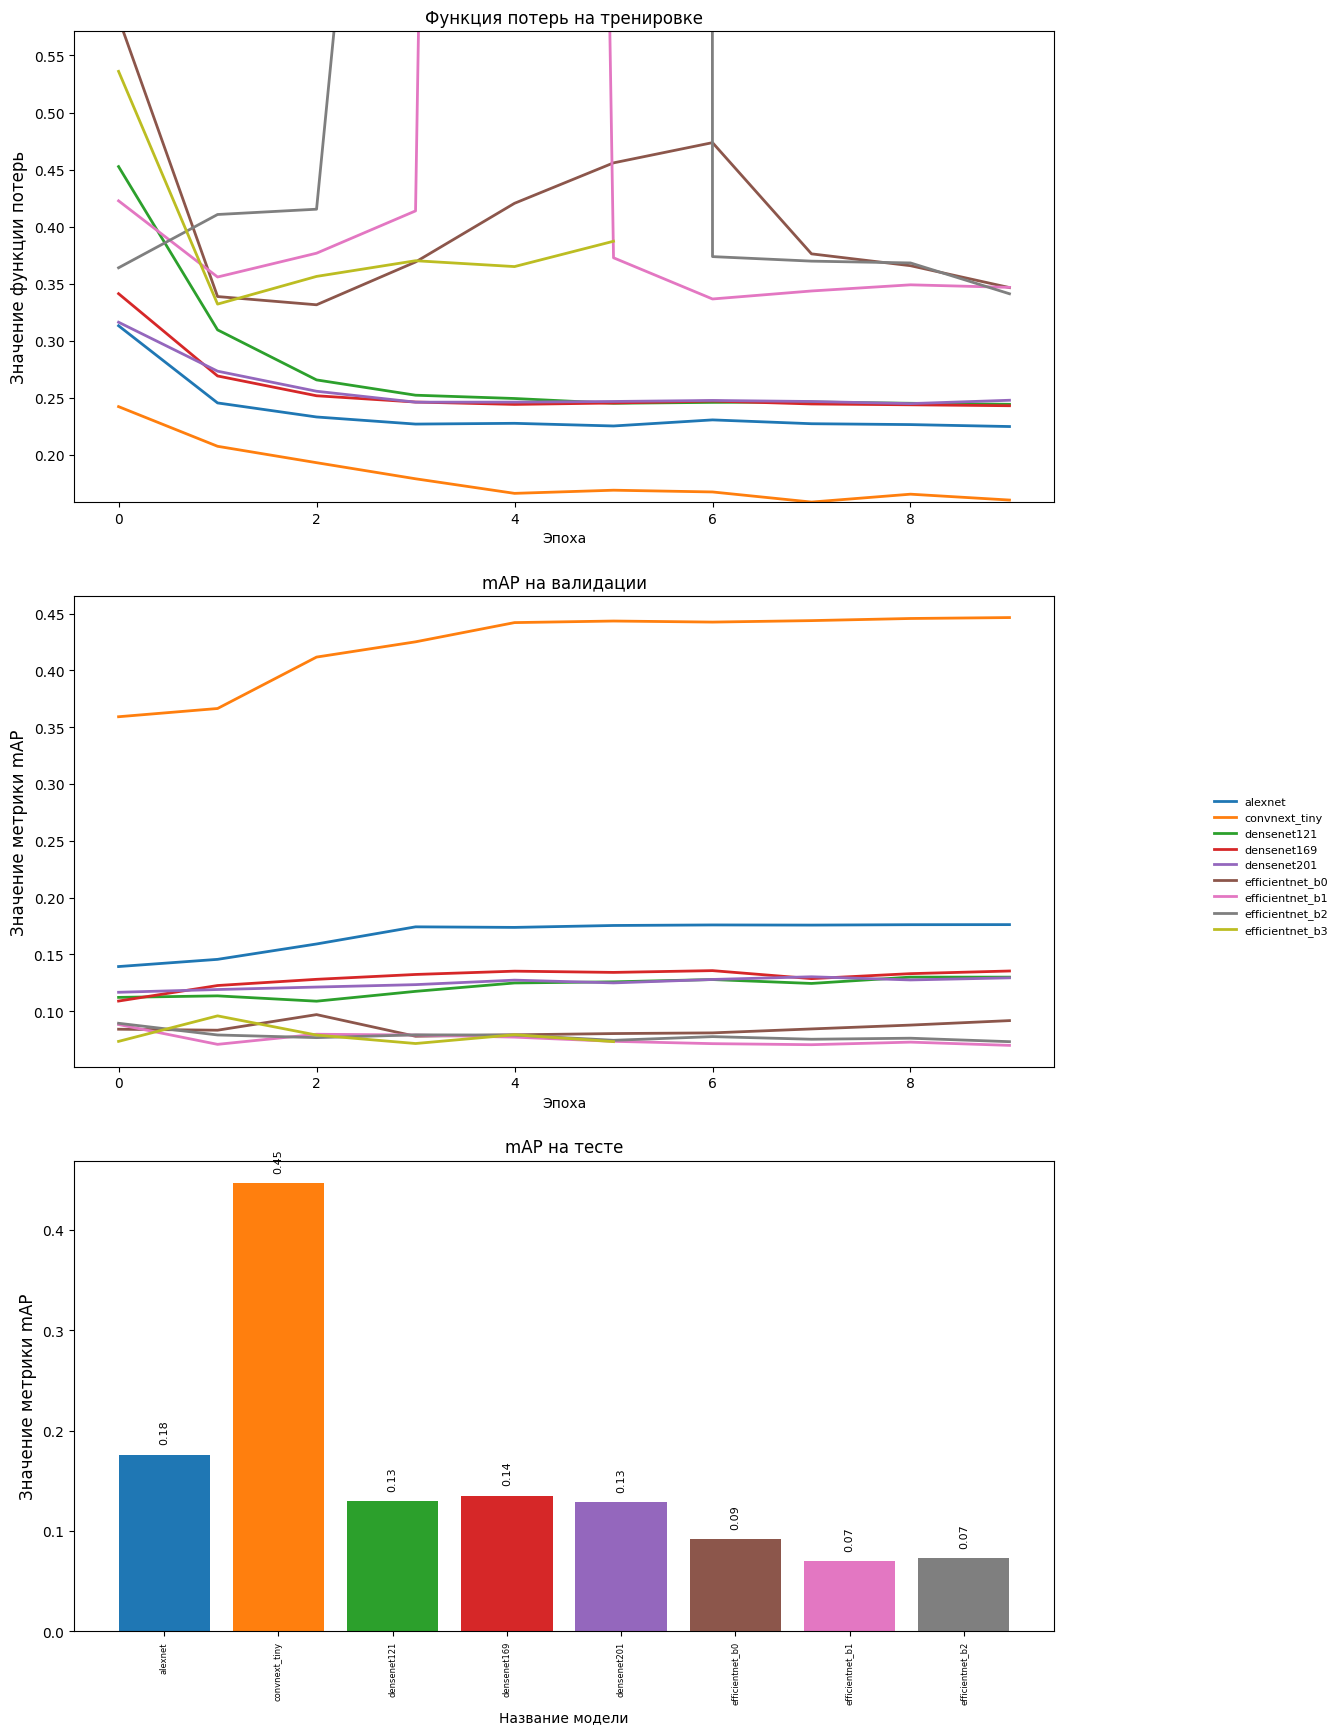

In [312]:
metrics_visualizer = MetricsVisualizer(prefix="Exp1",
                                       path_to_metrics_train="./metrics_train",
                                       path_to_metrics_test="./metrics_test",
                                       path_to_save_plots="./plot")

## Обучение лучшего бекбона

In [319]:
graduate_pipeline = validate_with_pydantic(EntryGraduateModel)(GraduateModelPipeline)(
    entry = {
        "prefix": "Exp2",
        "models": ["convnext_tiny"],
        "name_optimizers": ["SGD"],
        "size_img": (128, 128),
        "batch_size": 5,
        "num_epochs": 50,
        "emb_size": 512,
        "is_use_imagenet_weights": True,
        "use_device": "cuda",
        "start_learning_rate": 0.00055,
        "num_workers": 0,
        "pin_memory": True,
        "seed": 17
    }
)


        
        ----------------------------------------------------------------------
        
        Выбранная модель: convnext_tiny
        Пользовательское название модели: convnext_tiny_Exp2
        Выбранный оптимизатор: SGD
        
        ----------------------------------------------------------------------
        
        


Epoch 1/50 (Eval): 100%|███████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 73.39sample/s]



Epoch 1/50, Training Loss: 0.2420376272420981
mAP: 0.3592120204436654


Epoch 2/50 (Eval): 100%|███████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 64.26sample/s]



Epoch 2/50, Training Loss: 0.20725657729781233
mAP: 0.3664644670376315


...


Epoch 49/50, Training Loss: 0.16394865793699864
mAP: 0.44682093003238094


Epoch 50/50 (Eval): 100%|██████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 70.77sample/s]



Epoch 50/50, Training Loss: 0.16437969049729872
mAP: 0.44682116477425116
Тренировка завершена!


(Eval): 100%|██████████████████████████████████████████████████████████████████████| 55/55 [00:00<00:00, 72.32sample/s]


Test mAP: 0.44682116477425116


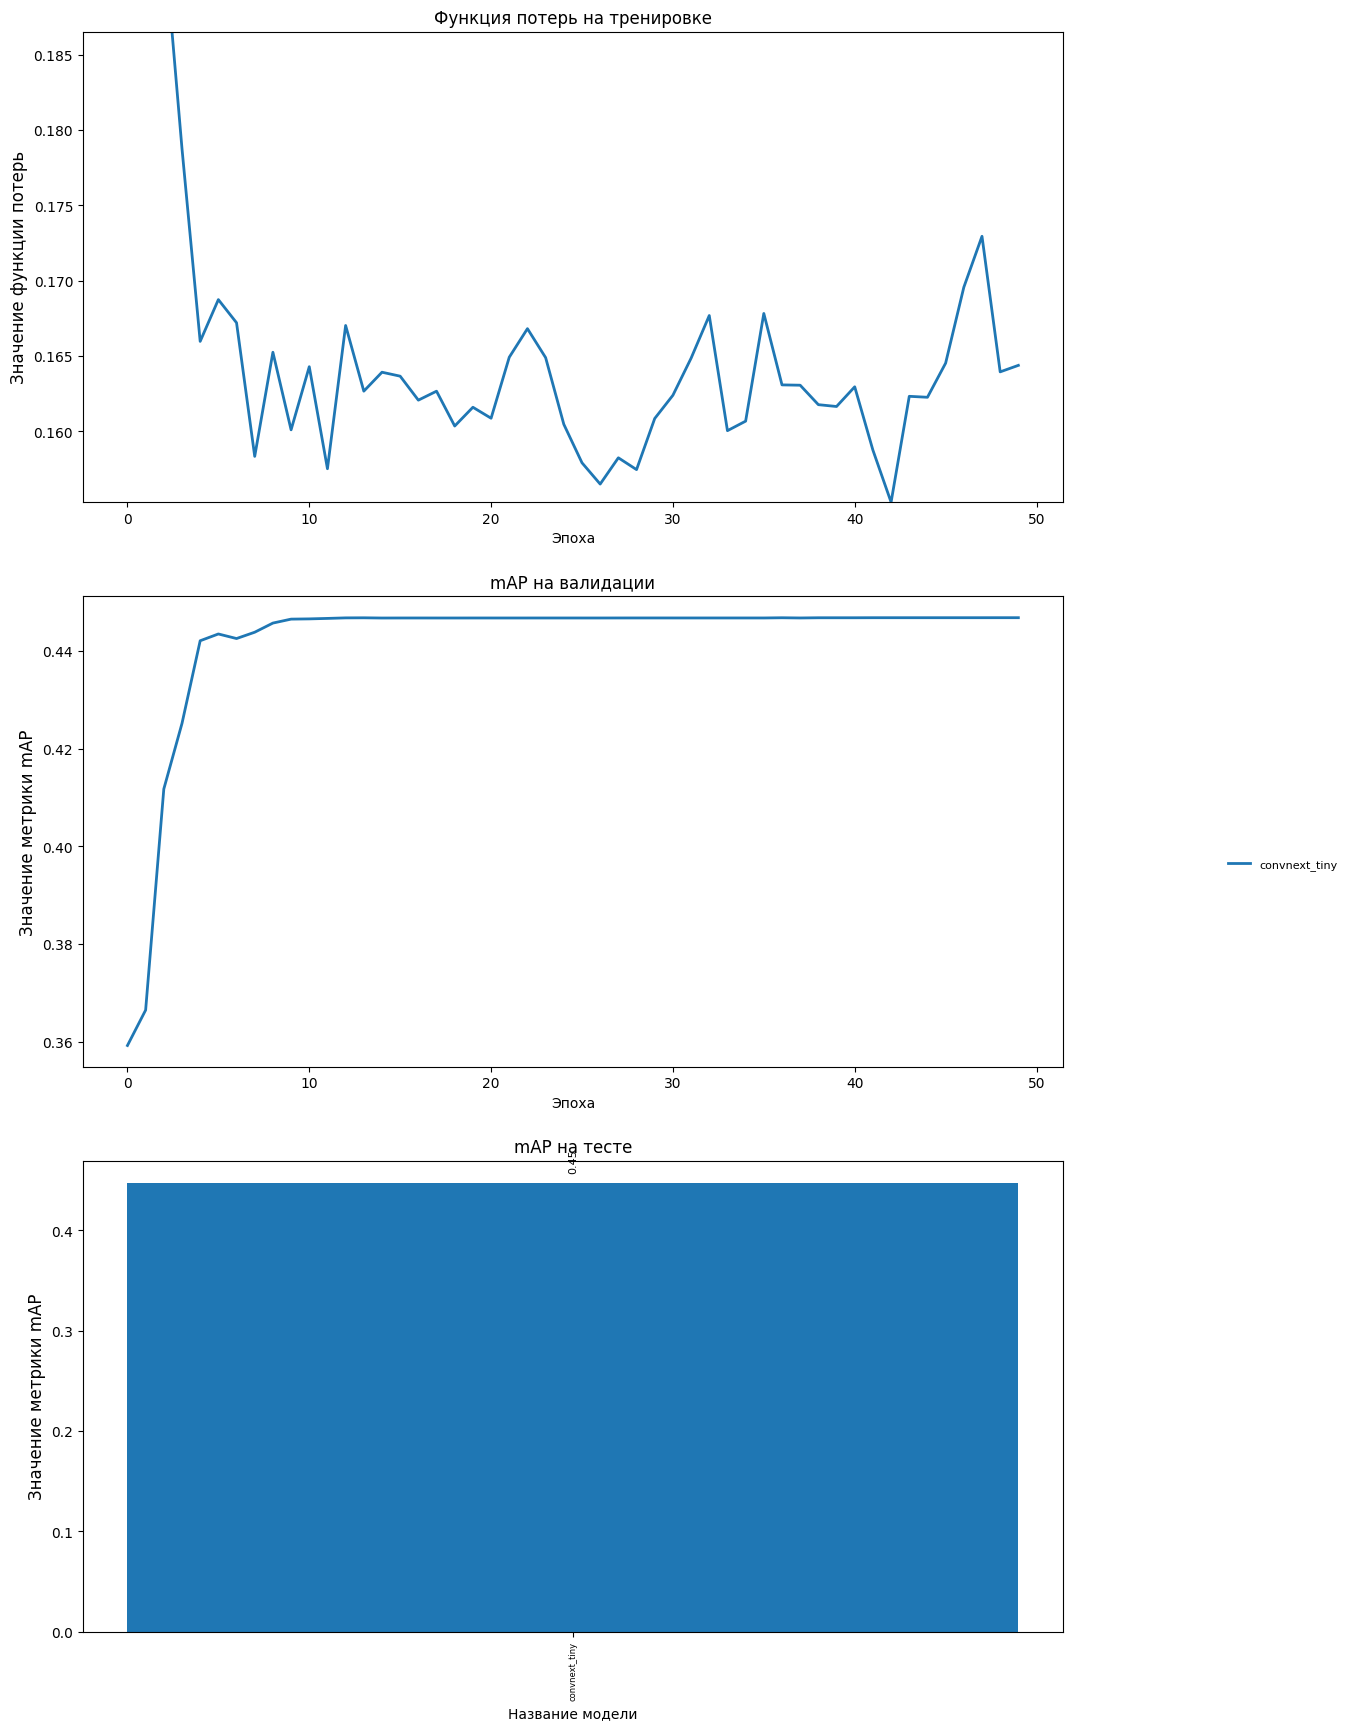

In [320]:
graduate_pipeline.graduate()

# Тестирование модели

## Инференс моделью

### Класс InferenceModel

In [370]:
class InferenceModel:
    def __init__(self,
                 model_name: str,
                 emb_size: int,
                 path_to_weights: str,
                 image_paths: list[str],
                 prefix: str = "",
                 use_device: str = None,
                 size_img: tuple = (128, 128),
                 labels: bool = False):
        self.name_model = model_name
        self.emb_size = emb_size
        self.path_to_weights = path_to_weights
        self.image_paths = image_paths
        self.size_img = size_img
        self.use_device = use_device
        self.device = None
        self.prefix = prefix
        self.labels = labels

        # Перемещение модели на GPU, если CUDA доступен
        if self.use_device == None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        elif self.use_device == "cuda":
            self.device = torch.device("cuda")
        elif self.use_device == "cpu":
            self.device = torch.device("cpu")
        else:
            raise Exception("use_device must be cuda or cpu or None")

    def get_model(self):
        # Инициализация сиамской сети
        self.model = SiameseNetwork(self.name_model, self.emb_size, False).to(self.device)

    def load_model(self):
        if self.prefix != "":
            path = os.path.join(self.path_to_weights, f"{self.name_model}_{self.prefix}.pt")
        else:
            path = os.path.join(self.path_to_weights, f"{self.name_model}.pt")
        try:
            if self.name_model in models.__dict__:
                if os.path.exists(path):
                    state_dict = torch.load(path, map_location=self.device)['model_state_dict']
                    self.model.load_state_dict(state_dict)
                    log.info(f"Модель {self.name_model} успешно загружена с весами из {self.path_to_weights}.")
            else:
                log.warning(f"Модель {self.name_model} не найдена.")
        except Exception as e:
            log.exception(f"Ошибка при загрузке модели: {e}")

    def get_transform(self):
        return transforms.Compose([
                ResizeWithPadding(self.size_img[0]),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],  # Средние значения для ImageNet
                    std=[0.229, 0.224, 0.225]    # Стандартные отклонения для ImageNet
                )
            ])

    def predict(self):
        self.get_model()
        self.load_model()
        self.model.eval()
        all_embeds = []
        all_labels = []

        with torch.no_grad():
            for image_path in tqdm(self.image_paths, desc="Extract Feature", unit="image"):
                try:
                    # Load image
                    image = Image.open(image_path).convert('RGB')
                    image = self.get_transform()(image).unsqueeze(0).to(self.device)

                    # Get label
                    if self.labels:
                        label = int(os.path.basename(image_path).split(".png")[0].split("_")[0])
                    else:
                        label = None
                        
                    all_labels.append(label)

                    # Inference
                    outputs = self.model.forward_once(image)
                    all_embeds += [out.cpu().numpy() for out in outputs]

                except Exception as e:
                    print(f"Ошибка при обработке изображения {image_path}: {e}")
                    all_embeds.append(None)

        if self.labels:
            mAP = calculate_map(all_embeds, all_labels)  # Вычисление mAP
            print(f"Inference mAP: {mAP}")

        return all_embeds, all_labels

### InferenceModelPipeline

In [371]:
@dataclass
class InferenceModelPipeline:
    entry: EntryInferenceModel

    def __post_init__(self):
        pass

    def inference(self):

        prefix = self.entry.Prefix
        name_model = self.entry.NameModel
        path_to_weights = self.entry.PathWeights
        image_path_list = self.entry.ImageList
        emb_size = self.entry.EmbSize
        use_device = self.entry.UseDevice
        size_img = self.entry.SizeImg
        labels = self.entry.Labels
        
        try:
            inference_model = InferenceModel(
                          prefix=prefix,
                          model_name=name_model,
                          path_to_weights=path_to_weights,
                          image_paths=image_path_list,
                          emb_size=emb_size,
                          use_device=use_device,
                          size_img=size_img,
                          labels=labels)
            all_embeds, all_labels = inference_model.predict()
            return all_embeds, all_labels
        except Exception as ex:
            log.exception("InferenceModel\n", exc_info=ex)

### Инференс

In [372]:
path_to_images = "./images"

# Получаем ембеддинги
inference_pipeline = validate_with_pydantic(EntryInferenceModel)(InferenceModelPipeline)(
    entry = {
        "prefix": "Exp2",
        "name_model": "convnext_tiny",
        "image_path_list": [os.path.join(path_to_images, path) for path in os.listdir(path_to_images)],
        "size_img": (128, 128),
        "emb_size": 512,
        "use_device": "cuda",
        "path_to_weights": "./weights",
        "labels": True
    }
)

In [373]:
all_embeds, all_labels = inference_pipeline.inference()

12:54:27-416027 INFO     Модель convnext_tiny успешно загружена с весами из ./weights.

Extract Feature: 100%|████████████████████████████████████████████████████████████| 272/272 [00:03<00:00, 88.97image/s]

Inference mAP: 0.5605753437519935


## Визуализация ембеддингов через TSNE

### Класс Emb2Tsne

In [375]:
class Emb2Tsne:
    def __init__(
        self,
        embeddings: list[np.ndarray],
        labels: List[int],
        n_components: int = 2,
        perplexity: float = 30.0,
        random_state: int = 42,
        **tsne_kwargs
    ):
        """
        Инициализация визуализатора t-SNE
        
        :param embeddings: Массив эмбеддингов (N_samples, 512)
        :param labels: Список меток классов для каждого эмбеддинга
        :param n_components: Размерность выходного пространства
        :param perplexity: Параметр перплексии для t-SNE
        :param random_state: Seed для воспроизводимости
        :param tsne_kwargs: Дополнительные параметры для TSNE
        """
        self.embeddings = np.stack(embeddings)
        self.labels = np.array(labels)
        self.n_components = n_components
        self.tsne = TSNE(
            n_components=n_components,
            perplexity=perplexity,
            random_state=random_state,
            **tsne_kwargs
        )
        self.tsne_results: Optional[np.ndarray] = None

    def fit_transform(self) -> np.ndarray:
        """Применяет t-SNE к эмбеддингам и возвращает 2D проекцию"""
        self.tsne_results = self.tsne.fit_transform(self.embeddings)
        return self.tsne_results

    def plot(
        self,
        figsize: tuple = (12, 8),
        title: str = "t-SNE Visualization",
        alpha: float = 0.7,
        marker_size: float = 8.0
    ) -> None:
        """Визуализирует 2D проекцию с цветовой маркировкой классов"""
        if self.tsne_results is None:
            raise ValueError("Сначала выполните fit_transform()")
            
        if len(np.unique(self.labels)) > 10:
            cmap = plt.cm.get_cmap('tab20')
        else:
            cmap = plt.cm.get_cmap('tab10')

        plt.figure(figsize=figsize)
        scatter = plt.scatter(
            self.tsne_results[:, 0],
            self.tsne_results[:, 1],
            c=self.labels,
            cmap=cmap,
            alpha=alpha,
            s=marker_size,
            edgecolors='w'
        )

        plt.title(title, pad=20)
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.colorbar(scatter, label="Classes")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

### Визуализируем

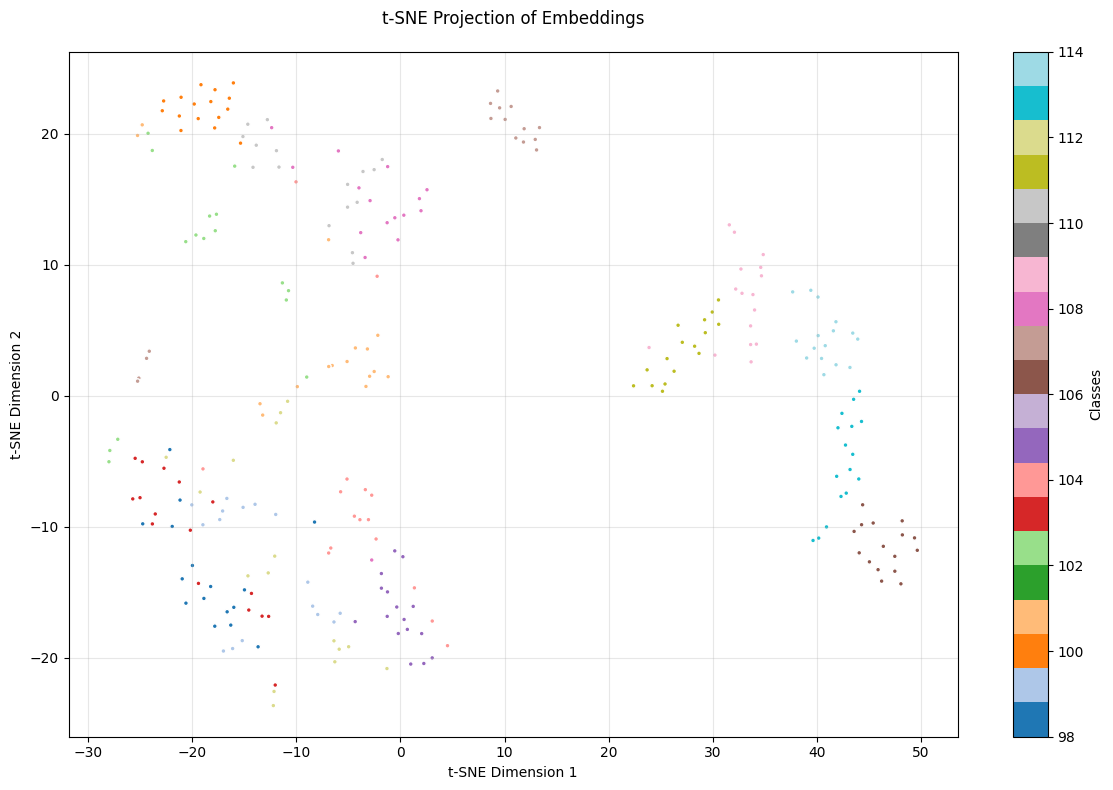

In [378]:
# Создание и использование визуализатора
visualizer = Emb2Tsne(
    embeddings=all_embeds,
    labels=all_labels,
    perplexity=15,
    random_state=42
)

# Получение 2D проекции
projection = visualizer.fit_transform()

# Визуализация
visualizer.plot(
    title="t-SNE Projection of Embeddings",
    alpha=1.0,
    marker_size=12.0
)

# Реализация нейросетевого трекинга

## Класс Tracker

In [390]:
TrackElement = collections.namedtuple(
    typename='TrackElement',
    field_names=['t', 'track_id', 'mask', 'mean', 'embed'],
)

def center_mass(masks: np.ndarray) -> np.ndarray:
    N = masks.shape[0]
    center_mass = np.empty((N, 2), dtype=np.float32)
    for i in range(N):
        xs, ys = masks[i].nonzero()
        center_mass[i, 0] = xs.mean()
        center_mass[i, 1] = ys.mean()
    return center_mass

class Tracker:
    def __init__(
        self,
        alive_threshold: int,
        association_threshold: float = 0.1,
        means_threshold: float = 150,
        min_value: float = -1e9,
        euclidean_scale: float = 1.344,
        euclidean_offset: float = 9.447,
        iou_scale: float = 0.402,
    ) -> None:
        self.alive_threshold = alive_threshold
        self.means_threshold = means_threshold
        self.association_threshold = association_threshold
        self.min_value = min_value
        self.active_tracks = []
        self.next_inst_id = None
        self.euclidean_scale = euclidean_scale
        self.euclidean_offset = euclidean_offset
        self.iou_scale = iou_scale

    def update_active_track(self, frame_count: int) -> None:
        self.active_tracks = [
            track for track in self.active_tracks
            if track.t >= frame_count - self.alive_threshold
        ]

    def tracking(
        self,
        frame_count: int,
        masks: np.ndarray,
        embeds: np.ndarray,
    ) -> list:
        if self.next_inst_id is None:
            self.next_inst_id = 1
        else:
            self.update_active_track(frame_count)

        n, k = len(masks), len(self.active_tracks)
        result = np.zeros(n, dtype=np.int32)

        if n < 1:
            return result

        means = center_mass(masks)
        masks = [maskUtils.encode(np.asfortranarray(mask)) for mask in masks.astype(np.uint8)]

        if k == 0:
            for i in range(n):
                self.active_tracks.append(
                    TrackElement(
                        t=frame_count,
                        mask=masks[i],
                        track_id=self.next_inst_id,
                        mean=means[i],
                        embed=embeds[i],
                    )
                )
                result[i] = self.next_inst_id
                self.next_inst_id += 1
            return result

        detections_unassigned = np.ones(n, dtype=bool)

        # Получаем эмбеддинги из памяти
        last_reids = np.array([track.embed for track in self.active_tracks])
        
        # Вычисляем матрицу схожести для эмбеддингов
        distance_matrix = cdist(embeds, last_reids, metric='euclidean')
        embed_sim = self.euclidean_scale * (self.euclidean_offset - distance_matrix)
        
        # Вычисляем матрицу IoU
        memory_masks = [track.mask for track in self.active_tracks]
        iou_matrix = maskUtils.iou(masks, memory_masks, [False]*len(memory_masks))
        asso_sim = embed_sim + self.iou_scale * iou_matrix

        # Применяем пороги и решаем задачу назначения
        asso_sim[asso_sim <= self.association_threshold] = self.min_value
        rows, cols = linear_sum_assignment(asso_sim, maximize=True)

        for row, column in zip(rows, cols):
            if np.linalg.norm(self.active_tracks[column].mean - means[row]) < self.means_threshold and asso_sim[row][column] != self.min_value:
                self.active_tracks[column] = TrackElement(
                    t=frame_count,
                    mask=masks[row],
                    track_id=self.active_tracks[column].track_id,
                    mean=means[row],
                    embed=embeds[row],
                )
                result[row] = self.active_tracks[column].track_id
            else:
                self.active_tracks.append(TrackElement(
                    t=frame_count,
                    mask=masks[row],
                    track_id=self.next_inst_id,
                    mean=means[row],
                    embed=embeds[row],
                ))
                result[row] = self.next_inst_id
                self.next_inst_id += 1
            detections_unassigned[row] = False

        for i in detections_unassigned.nonzero()[0]:
            self.active_tracks.append(TrackElement(
                t=frame_count,
                mask=masks[i],
                track_id=self.next_inst_id,
                mean=means[i],
                embed=embeds[i],
            ))
            result[i] = self.next_inst_id
            self.next_inst_id += 1

        return result

## Функция для получения эмбеддингов по известным детекциям

In [391]:
def get_embeddings(
    img: np.ndarray,
    preds_bboxes: np.ndarray,
    emb_size: int,
    size_img: Tuple[int, int],
    prefix: str,
    name_model: str,
    path_to_weights: str = "./weights"
) -> np.ndarray:
    '''
    Функция для получения эмбеддингов изображения по bounding boxes.

    Входные параметры:
    img - np.ndarray: Входное изображение (H, W, C).
    preds_bboxes - np.ndarray: Предсказанные bounding boxes (N, 4) в формате [x1, y1, x2, y2].
    emb_size - int: Размер эмбеддингов модели.
    size_img - Tuple[int, int]: Размер изображений, на котором обучалась модель (H, W).
    prefix - str: Префикс модели.
    name_model - str: Название модели.
    path_to_weights - str: Путь к весам модели.

    Выходные параметры:
    np.ndarray: Эмбеддинги для каждого bounding box (N, emb_size).
    '''
    # Создаем временную директорию для сохранения обрезанных изображений
    with tempfile.TemporaryDirectory() as temp_dir:
        image_paths = []

        # Обрезаем изображение по каждому bounding box и сохраняем во временную директорию
        for i, bbox in enumerate(preds_bboxes):
            x1, y1, x2, y2 = map(int, bbox)
            cropped_img = img[y1:y2, x1:x2]  # Обрезаем изображение
            cropped_img = Image.fromarray(cropped_img)  # Конвертируем в PIL Image
            cropped_img = cropped_img.resize(size_img)  # Ресайзим до нужного размера

            # Сохраняем обрезанное изображение во временную директорию
            temp_image_path = os.path.join(temp_dir, f"cropped_{i}.jpg")
            cropped_img.save(temp_image_path)
            image_paths.append(temp_image_path)

        # Инициализируем модель для получения эмбеддингов
        inference_model = InferenceModel(
            prefix=prefix,
            model_name=name_model,
            path_to_weights=path_to_weights,
            image_paths=image_paths,
            emb_size=emb_size,
            use_device="cuda",
            size_img=size_img,
            labels=False
        )

        # Получаем эмбеддинги
        all_embeds, all_labels = inference_model.predict()

    # Возвращаем эмбеддинги в виде numpy массива
    return np.stack(all_embeds, axis=0)

## Скрипты для визуализации предсказаний

In [392]:
# код с семинара
class YoloDetector:
    def __init__(self, conf_threshold: float = 0.3) -> None:
        self.model = YOLO("yolov8s-seg.pt")
        self.conf_threshold = conf_threshold

    def __call__(self, img_path: np.ndarray) -> np.ndarray:
        preds = self.model.predict(source=img_path, conf=self.conf_threshold, show=False, verbose=False, classes=0)
        preds_masks = preds[0].masks.data.to(torch.bool).cpu().numpy()
        preds_bboxes = preds[0].boxes.xyxy.cpu().numpy()
        return preds_masks, preds_bboxes

def tracking_visualization(
    img: np.ndarray,
    preds: np.ndarray,
) -> np.ndarray:
    '''
    Входные данные:
    img: np.ndarray - изображение для отрисовки
    preds: np.ndarray - маски сегментации
    '''
    for i in range(len(preds)):
        # отрисуем ограничивающий прямоугольник
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=1,
        )
        # отрисуем track_id
        cv2.putText(
            img,
            str(int(preds[i][4])),
            (int(preds[i][0] + 10), int(preds[i][1] + 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=1,
            color=(0, 255, 0),
            thickness=1,
        )

    return img

# Оцениваем работу трекера

## Скачиваем видео

In [384]:
# скачаем тестовое видео
!wget https://motchallenge.net/sequenceVideos/MOT20-02-raw.mp4 -O mot20.mp4

--2025-02-25 13:17:11--  https://motchallenge.net/sequenceVideos/MOT20-02-raw.mp4
Resolving motchallenge.net (motchallenge.net)... 131.159.19.34, 2a09:80c0:18::1034
Connecting to motchallenge.net (motchallenge.net)|131.159.19.34|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 76066403 (73M) [video/mp4]
Saving to: 'mot20.mp4'

     0K .......... .......... .......... .......... ..........  0%  453K 2m44s
    50K .......... .......... .......... .......... ..........  0%  960K 2m1s
   100K .......... .......... .......... .......... ..........  0% 33,6M 81s
   150K .......... .......... .......... .......... ..........  0% 20,5M 62s
   200K .......... .......... .......... .......... ..........  0% 1023K 64s
   250K .......... .......... .......... .......... ..........  0%  926K 66s
   300K .......... .......... .......... .......... ..........  0% 91,5M 57s
   350K .......... .......... .......... .......... ..........  0%  678M 50s
   400K .......... ........

## Класс VideoTracker

In [396]:
class VideoTracker:
    def __init__(
        self,
        video_path: str,
        output_path: str,
        detector,
        tracker,
        cut_number_frames: int = 200,
        emb_size: int = 512,
        size_img: Tuple[int, int] = (128, 128),
        prefix: str = "Exp2",
        name_model: str = "convnext_tiny",
        path_to_weights: str = "./weights",
    ):
        """
        Инициализация трекера видео.

        :param video_path: Путь к входному видео.
        :param output_path: Путь для сохранения выходного видео.
        :param detector: Объект детектора (например, YoloDetector).
        :param tracker: Объект трекера (например, Tracker).
        :param cut_number_frames: Максимальное количество кадров для обработки.
        :param emb_size: Размер эмбеддингов.
        :param size_img: Размер изображений для модели.
        :param prefix: Префикс модели.
        :param name_model: Название модели.
        :param path_to_weights: Путь к весам модели.
        """
        self.video_path = video_path
        self.output_path = output_path
        self.detector = detector
        self.tracker = tracker
        self.cut_number_frames = cut_number_frames
        self.emb_size = emb_size
        self.size_img = size_img
        self.prefix = prefix
        self.name_model = name_model
        self.path_to_weights = path_to_weights

    def _get_embeddings(self, frame: np.ndarray, preds_bboxes: np.ndarray) -> np.ndarray:
        """
        Получение эмбеддингов для bounding boxes.

        :param frame: Входное изображение.
        :param preds_bboxes: Bounding boxes (N, 4).
        :return: Эмбеддинги (N, emb_size).
        """
        return get_embeddings(
            img=frame,
            preds_bboxes=preds_bboxes,
            emb_size=self.emb_size,
            size_img=self.size_img,
            prefix=self.prefix,
            name_model=self.name_model,
            path_to_weights=self.path_to_weights,
        )

    def _tracking_visualization(self, frame: np.ndarray, preds: np.ndarray) -> np.ndarray:
        """
        Визуализация трекинга на кадре.

        :param frame: Входное изображение.
        :param preds: Данные для визуализации (N, 5) — [x1, y1, x2, y2, track_id].
        :return: Изображение с визуализацией.
        """
        # Пример реализации (замените на вашу функцию визуализации)
        for pred in preds:
            x1, y1, x2, y2, track_id = map(int, pred)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, str(track_id), (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        return frame

    def process_video(self):
        """
        Обработка видео: детекция, трекинг и визуализация.
        """
        try:
            cap = cv2.VideoCapture(self.video_path)
            if not cap.isOpened():
                raise ValueError("Ошибка при открытии видео")
    
            frame_size = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
            length = min(self.cut_number_frames, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
            fps = cap.get(cv2.CAP_PROP_FPS)
            fourcc = cv2.VideoWriter_fourcc(*'avc1')
            video_writer = cv2.VideoWriter(self.output_path, fourcc, fps, frame_size)
    
            frame_count = 0
            pbar = tqdm(total=length)
    
            while True:
                ret, frame = cap.read()
                if not ret or frame_count > self.cut_number_frames:
                    print("Стрим закончился")
                    break
    
                # Конвертируем изображение в RGB
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
                # Детекция
                preds_masks, preds_bboxes = self.detector(frame)
    
                # Получение эмбеддингов
                embeds = self._get_embeddings(frame, preds_bboxes)
    
                # Трекинг
                track_ids = self.tracker.tracking(frame_count=frame_count, masks=preds_masks, embeds=embeds)
                preds = np.column_stack([preds_bboxes, track_ids])
    
                # Визуализация
                out_frame = self._tracking_visualization(frame, preds)
                video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
    
                frame_count += 1
                pbar.update(1)

            for path in [self.output_path]:
                os.system(f'ffmpeg -y -i "{path}" -c:v libx264 -pix_fmt yuv420p "{path}"')
                
        finally:
            video_writer.release()
            cap.release()
            pbar.close()

## Запускаем трекер

In [397]:
detector = YoloDetector()
tracker = Tracker(5)

video_tracker = VideoTracker(
    video_path="mot20.mp4",
    output_path="mot20_vis.mp4",
    detector=detector,
    tracker=tracker,
    cut_number_frames=200,
    emb_size=512,
    size_img=(128, 128),
    prefix="Exp2",
    name_model="convnext_tiny",
    path_to_weights="./weights",
)

video_tracker.process_video()


%|                                                                                          | 0/200 [00:00<?, ?it/s]

13:32:40-902608 INFO     Модель convnext_tiny успешно загружена с весами из ./weights.



t Feature:   0%|                                                                       | 0/20 [00:00<?, ?image/s]

Extract Feature: 100%|██████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 99.77image/s]

%|▍                                                                                 | 1/200 [00:01<03:55,  1.18s/it]

13:32:41-623412 INFO     Модель convnext_tiny успешно загружена с весами из ./weights.



t Feature:   0%|                                                                       | 0/17 [00:00<?, ?image/s]

Extract Feature: 100%|██████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 94.71image/s]

%|▊                                                                                 | 2/200 [00:01<02:57,  1.12it/s]

...

13:35:08-304883 INFO     Модель convnext_tiny успешно загружена с весами из ./weights.



t Feature:   0%|                                                                       | 0/15 [00:00<?, ?image/s]

Extract Feature: 100%|██████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 87.97image/s]

%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:28<00:00,  1.36it/s]

13:35:09-015819 INFO     Модель convnext_tiny успешно загружена с весами из ./weights.



t Feature:   0%|                                                                       | 0/17 [00:00<?, ?image/s]

Extract Feature: 100%|██████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 84.64image/s]

201it [02:29,  1.35it/s]                                                                                               

Стрим закончился


In [402]:
os.system(f'ffmpeg -y -i "./mot20_vis.mp4" -c:v libx264 -pix_fmt yuv420p "./mot20_vis_new.mp4"')

0

In [404]:
html = f"""
<div style="display:flex; gap:20px;">
    <div>
        <h4>Исходное видео </h4>
        <video width="800" controls autoplay muted loop>
            <source src="./mot20_vis_new.mp4" type="video/mp4">
        </video>
    </div>
</div>
"""
display(HTML(html))

<IPython.core.display.HTML object>

# Выводы

<hr style="border: 1px solid rgba(50, 50, 255, 0.5); width: 100%;">

<pre style="background-color: #888888; padding: 10px; border-radius: 5px; font-family: monospace;">
    <span style="color: white;">
        В целом все неплохо работает, всем советую
    </span>
</pre>

<hr style="border: 1px solid rgba(50, 50, 255, 0.5); width: 100%;">